# (IIP314W-2) [2026-T2] OPTIMIZACIÃ“N APLICADA A NEGOCIOS
## AyudantÃ­a 3: Condiciones de Karush-Kuhn-Tucker (KKT) â€” Pauta (SoluciÃ³n)

---

**Profesor:** Rodrigo Trigo Vilches

**Ayudante:** Vicente RamÃ­rez

**Fecha:** 17 de junio de 2026

**Universidad del Desarrollo**

---

## Objetivos de la ayudantÃ­a

- Plantear el **Lagrangiano generalizado** para problemas con restricciones de **desigualdad**.
- Aplicar las **condiciones de Karush-Kuhn-Tucker (KKT)**: estacionariedad, holgura complementaria, factibilidad primal y no negatividad de los multiplicadores.
- Usar la **holgura complementaria** para identificar el conjunto de restricciones **activas** (anÃ¡lisis de casos).
- Interpretar los multiplicadores $\mu_i$ como **precios sombra** y conectarlos con las holguras (*slacks*) y los duales que entrega `gurobipy`.
- Confirmar las soluciones con `scipy.optimize` y con `gurobipy`.

## Repaso breve de conceptos

**Forma general del problema.** Todo se escribe en **minimizaciÃ³n**:
$$\min\; f(x) \quad \text{s.a.} \quad g_i(x) \le 0,\; i=1,\dots,n, \qquad h_j(x) = 0,\; j=1,\dots,m.$$

**Lagrangiano generalizado** (un multiplicador por restricciÃ³n):
$$L(x,\mu,\lambda) = f(x) + \sum_{i=1}^{n}\mu_i\,g_i(x) + \sum_{j=1}^{m}\lambda_j\,h_j(x).$$

**Condiciones KKT.** Si $x^*$ es un mÃ­nimo local y se cumplen las condiciones de regularidad (Clase 6â€“7), existen multiplicadores $\mu_i \ge 0$ y $\lambda_j$ tales que:

| CondiciÃ³n | ExpresiÃ³n |
|:--|:--|
| **Estacionariedad** | $\nabla f(x^*) + \sum_i \mu_i \nabla g_i(x^*) + \sum_j \lambda_j \nabla h_j(x^*) = \mathbf{0}$ |
| **Holgura complementaria** | $\mu_i\,g_i(x^*) = 0 \quad \forall i$ |
| **Factibilidad primal** | $g_i(x^*) \le 0,\quad h_j(x^*) = 0$ |
| **Factibilidad dual** | $\mu_i \ge 0 \quad \forall i$ |

**La idea clave (holgura complementaria).** Para cada restricciÃ³n de desigualdad, *o* el multiplicador es cero ($\mu_i = 0$, restricciÃ³n **inactiva**, sobra holgura), *o* la restricciÃ³n se cumple con igualdad ($g_i(x^*)=0$, restricciÃ³n **activa**). Resolver KKT "a mano" es, esencialmente, **probar combinaciones de restricciones activas/inactivas** (anÃ¡lisis de casos) y quedarse con la que cumple *todo*: factibilidad y $\mu_i \ge 0$.

**Suficiencia (convexidad).** Si $f$ y las $g_i$ son convexas y las $h_j$ afines, las condiciones KKT no solo son necesarias sino **suficientes**: cualquier punto que las satisface es Ã³ptimo global (Clase 6â€“7).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## Ejercicio 1 â€” Mezcla de producciÃ³n (KKT a mano, problema lineal)

Una fÃ¡brica produce dos artÃ­culos en cantidades $x \ge 0$ e $y \ge 0$ (en miles de unidades). El **margen** por cada mil unidades es de 5 y 4 (en millones de pesos), de modo que se busca:

$$\max\; Z = 5x + 4y$$

La producciÃ³n estÃ¡ limitada por dos recursos:

$$R_1:\; 2x + 3y \le 12 \quad (\text{horas mÃ¡quina}) \qquad R_2:\; 2x + y \le 8 \quad (\text{horas de mano de obra})$$

**Tareas:**
1. Escribir el problema en forma de minimizaciÃ³n y plantear el **Lagrangiano generalizado** con multiplicadores $\mu_1,\mu_2 \ge 0$.
2. Escribir las cuatro condiciones KKT. Mediante **holgura complementaria**, suponer que ambas restricciones estÃ¡n activas, resolver el sistema lineal y **verificar** que $\mu_1,\mu_2 \ge 0$ y que la soluciÃ³n es factible.
3. Confirmar el Ã³ptimo con `scipy.optimize.linprog`.

### SoluciÃ³n analÃ­tica

En minimizaciÃ³n: $\min\, f = -5x - 4y$, con $g_1 = 2x+3y-12 \le 0$ y $g_2 = 2x+y-8 \le 0$. Suponiendo el interior ($x,y>0$, no negatividad inactiva), el Lagrangiano es

$$L = -5x - 4y + \mu_1(2x+3y-12) + \mu_2(2x+y-8).$$

**Estacionariedad:**
$$\frac{\partial L}{\partial x}:\; -5 + 2\mu_1 + 2\mu_2 = 0 \qquad \frac{\partial L}{\partial y}:\; -4 + 3\mu_1 + \mu_2 = 0$$

**Holgura complementaria â€” caso "ambas activas"** ($g_1=0,\;g_2=0$):
$$2x+3y = 12, \qquad 2x+y = 8 \;\Rightarrow\; 2y = 4 \;\Rightarrow\; y = 2,\; x = 3.$$

Resolviendo la estacionariedad: $\mu_1+\mu_2 = 2.5$ y $3\mu_1+\mu_2 = 4 \Rightarrow \mu_1 = 0.75,\; \mu_2 = 1.75$.

$$\boxed{(x^*,y^*) = (3,2),\quad \mu_1 = 0.75,\; \mu_2 = 1.75,\quad Z^* = 23}$$

**VerificaciÃ³n KKT:** $\mu_1,\mu_2 > 0$ âœ”; factibilidad $x,y>0$ âœ”; ambas activas (holgura 0) âœ”. Como el problema es lineal (convexo), KKT es **suficiente**: $(3,2)$ es Ã³ptimo global. Los demÃ¡s casos (alguna inactiva) dan multiplicadores negativos o puntos no Ã³ptimos, por eso se descartan.

In [2]:
# Caso "ambas restricciones activas": sistema lineal con incognitas [x, y, mu1, mu2]
# Estacionariedad:  2*mu1 + 2*mu2 = 5 ;  3*mu1 + mu2 = 4
# Restricciones activas:  2x + 3y = 12 ;  2x + y = 8
A = np.array([[0, 0, 2, 2],
              [0, 0, 3, 1],
              [2, 3, 0, 0],
              [2, 1, 0, 0]], dtype=float)
b = np.array([5, 4, 12, 8], dtype=float)
x, y, mu1, mu2 = np.linalg.solve(A, b)
print(f"(x*, y*) = ({x:.2f}, {y:.2f}) | mu1 = {mu1:.4f}, mu2 = {mu2:.4f}")
print(f"Z* = {5*x + 4*y:.2f}")
print(f"KKT: mu1>=0 y mu2>=0 ? {mu1 >= 0 and mu2 >= 0}  |  factible ? "
      f"{2*x+3*y <= 12+1e-9 and 2*x+y <= 8+1e-9 and x >= 0 and y >= 0}")

(x*, y*) = (3.00, 2.00) | mu1 = 0.7500, mu2 = 1.7500
Z* = 23.00
KKT: mu1>=0 y mu2>=0 ? True  |  factible ? True


In [3]:
# Confirmacion con scipy.optimize.linprog (minimiza, por eso c = [-5, -4])
from scipy.optimize import linprog
c = [-5, -4]
A_ub = [[2, 3], [2, 1]]
b_ub = [12, 8]
res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None), (0, None)])
print("linprog -> (x*, y*) =", np.round(res.x, 4), "| Z* =", round(-res.fun, 4))
print("Holguras (b - A x):", np.round(np.array(b_ub) - np.array(A_ub) @ res.x, 4))

linprog -> (x*, y*) = [3. 2.] | Z* = 23.0
Holguras (b - A x): [0. 0.]


### DiscusiÃ³n

La gran novedad respecto de Lagrange (igualdad) es la **holgura complementaria**: no sabemos de antemano quÃ© restricciones limitan el Ã³ptimo, asÃ­ que **probamos un conjunto activo** y validamos con $\mu_i \ge 0$ + factibilidad. AquÃ­ ambos recursos resultaron cuellos de botella ($\mu_1,\mu_2>0$), por lo que ambas restricciones estÃ¡n activas. Un multiplicador grande seÃ±ala el recurso mÃ¡s "valioso": cada hora extra de mano de obra ($\mu_2=1.75$) aporta mÃ¡s al margen que una hora de mÃ¡quina ($\mu_1=0.75$). En el Ejercicio 3 veremos que esto es exactamente el **precio sombra** que reporta Gurobi.

## Ejercicio 2 â€” InversiÃ³n con un tope de presupuesto (KKT no lineal, anÃ¡lisis de casos)

Una empresa invierte en dos campaÃ±as, $x$ e $y$ (millones de pesos, $\ge 0$). La **utilidad** (millones) es

$$U(x,y) = 40x + 60y - 2x^2 - 3y^2.$$

A diferencia de la AyudantÃ­a 2, ahora el presupuesto es un **tope** (desigualdad), no una igualdad: la empresa **no estÃ¡ obligada** a gastarlo todo.

$$R:\; x + y \le 15$$

**Tareas:**
1. Escribir el problema en minimizaciÃ³n y plantear KKT con un multiplicador $\mu \ge 0$.
2. Resolver por **anÃ¡lisis de casos** sobre la holgura complementaria:
   - **Caso A** ($\mu = 0$, restricciÃ³n inactiva): resolver $\nabla U = \mathbf{0}$ y comprobar si el Ã³ptimo libre es factible.
   - **Caso B** ($\mu > 0$, restricciÃ³n activa): resolver con $x+y = 15$.
3. Quedarse con el caso que cumple todas las condiciones KKT y confirmarlo con `scipy.optimize.minimize` (SLSQP).

### SoluciÃ³n analÃ­tica

En minimizaciÃ³n: $\min\, f = -40x-60y+2x^2+3y^2$, con $g = x+y-15 \le 0$. Lagrangiano: $L = f + \mu\,(x+y-15)$.

**Estacionariedad:** $\;-40 + 4x + \mu = 0,\qquad -60 + 6y + \mu = 0.$

**Caso A â€” $\mu = 0$ (inactiva).** Entonces $x = 10,\; y = 10$. Pero $x+y = 20 > 15$: **infactible**. Se descarta.

**Caso B â€” $\mu > 0$ (activa), $x+y = 15$.** De estacionariedad $x = \dfrac{40-\mu}{4},\; y = \dfrac{60-\mu}{6}$. Sustituyendo en $x+y=15$:
$$\frac{40-\mu}{4} + \frac{60-\mu}{6} = 15 \;\Rightarrow\; 240 - 5\mu = 180 \;\Rightarrow\; \mu = 12.$$
Luego $x^* = 7,\; y^* = 8$, con $\mu = 12 > 0$ âœ” y $x,y \ge 0$ âœ”.

$$\boxed{(x^*,y^*) = (7,8),\quad \mu = 12,\quad U(7,8) = 470}$$

Como $U$ es cÃ³ncava (se maximiza una funciÃ³n cÃ³ncava sobre un conjunto convexo), KKT es suficiente: $(7,8)$ es el Ã³ptimo global.

In [4]:
# Resolucion simbolica de los dos casos con sympy
x, y, mu = sp.symbols('x y mu', real=True)
U = 40*x + 60*y - 2*x**2 - 3*y**2
estac = [sp.diff(-U, x) + mu*1, sp.diff(-U, y) + mu*1]   # grad(-U) + mu*grad(g) = 0

# Caso A: mu = 0
solA = sp.solve([e.subs(mu, 0) for e in estac], (x, y), dict=True)[0]
factibleA = (solA[x] + solA[y]) <= 15
print(f"Caso A (mu=0): {solA}, x+y={solA[x]+solA[y]} -> "
      f"{'factible' if factibleA else 'INFACTIBLE, se descarta'}")

# Caso B: restriccion activa x + y = 15
solB = sp.solve(estac + [x + y - 15], (x, y, mu), dict=True)[0]
print(f"Caso B (activa): {solB}  ->  mu = {solB[mu]} "
      f"{'(>=0, valido)' if solB[mu] >= 0 else '(<0, se descarta)'}")
print("U(x*, y*) =", U.subs({x: solB[x], y: solB[y]}))

Caso A (mu=0): {x: 10, y: 10}, x+y=20 -> INFACTIBLE, se descarta
Caso B (activa): {mu: 12, x: 7, y: 8}  ->  mu = 12 (>=0, valido)
U(x*, y*) = 470


In [5]:
# Confirmacion numerica con scipy.optimize.minimize (SLSQP)
from scipy.optimize import minimize
neg_U = lambda v: -(40*v[0] + 60*v[1] - 2*v[0]**2 - 3*v[1]**2)
restr = [{'type': 'ineq', 'fun': lambda v: 15 - v[0] - v[1]}]   # x+y <= 15  ==  15-x-y >= 0
res = minimize(neg_U, x0=[1.0, 1.0], method='SLSQP', bounds=[(0, None), (0, None)], constraints=restr)
print("scipy -> (x*, y*) =", np.round(res.x, 4), "| U* =", round(-res.fun, 4))

scipy -> (x*, y*) = [7. 8.] | U* = 470.0


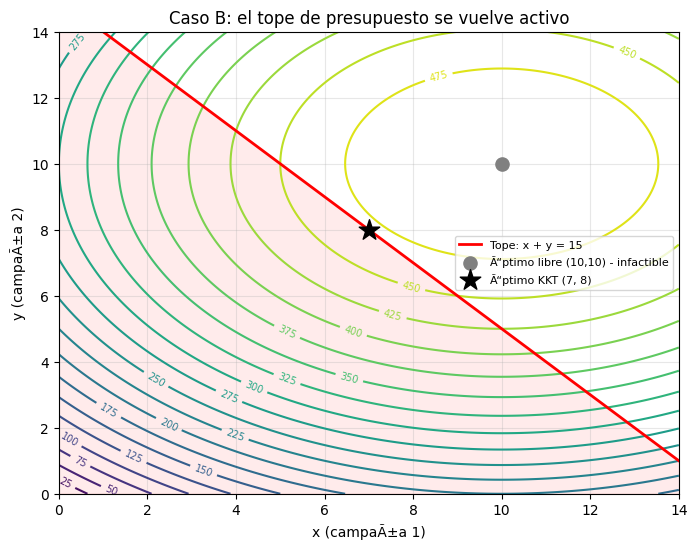

In [6]:
# Grafico: curvas de nivel de U, la recta del tope de presupuesto y el optimo
Uf = lambda x, y: 40*x + 60*y - 2*x**2 - 3*y**2
xv = np.linspace(0, 14, 300); yv = np.linspace(0, 14, 300)
X, Y = np.meshgrid(xv, yv)
plt.figure(figsize=(8, 6))
cs = plt.contour(X, Y, Uf(X, Y), levels=20, cmap='viridis')
plt.clabel(cs, inline=True, fontsize=7)
xr = np.linspace(0, 15, 100)
plt.plot(xr, 15 - xr, 'r-', lw=2, label='Tope: x + y = 15')
plt.fill_between(xr, 0, 15 - xr, color='red', alpha=0.08)
plt.scatter([10], [10], color='gray', marker='o', s=90, zorder=5, label='Ã“ptimo libre (10,10) - infactible')
plt.scatter([7], [8], color='black', marker='*', s=240, zorder=6, label='Ã“ptimo KKT (7, 8)')
plt.xlabel('x (campaÃ±a 1)'); plt.ylabel('y (campaÃ±a 2)')
plt.title('Caso B: el tope de presupuesto se vuelve activo')
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.xlim(0, 14); plt.ylim(0, 14)
plt.show()

### DiscusiÃ³n

Lo esencial de KKT con desigualdades: **una restricciÃ³n de tope solo "pesa" si limita**. El Ã³ptimo libre $(10,10)$ habrÃ­a gastado 20 > 15, asÃ­ que el presupuesto se vuelve **activo** y empuja la soluciÃ³n a $(7,8)$ sobre la recta $x+y=15$. El multiplicador $\mu = 12 > 0$ mide cuÃ¡nto subirÃ­a la utilidad por cada millÃ³n adicional de presupuesto. Si el tope hubiera sido $\ge 20$, habrÃ­amos quedado en el Caso A con $\mu=0$ y la restricciÃ³n serÃ­a irrelevante. Comparado con la AyudantÃ­a 2 (presupuesto **obligatorio**, igualdad), aquÃ­ el modelo decide *endÃ³genamente* si conviene gastar todo.

## Ejercicio 3 â€” Cuatro restricciones y precios sombra (holgura complementaria con KKT â†” Gurobi)

Una planta de manufactura produce dos productos en cantidades $x \ge 0$ e $y \ge 0$ (miles de unidades), con un margen de 4 y 3 (en millones de pesos). Se busca:

$$\max\; Z = 4x + 3y$$

sujeta a **cuatro** recursos, **ninguno redundante** (cada uno define un lado distinto de la regiÃ³n factible):

$$R_1:\; 3x + y \le 15 \;\;(\text{mecanizado}) \qquad R_2:\; x + y \le 7 \;\;(\text{ensamblaje})$$
$$R_3:\; x + 3y \le 15 \;\;(\text{pintura}) \qquad R_4:\; 2y \le 9 \;\;(\text{empaque del producto } y)$$

**Tareas:**
1. Graficar la regiÃ³n factible y comprobar visualmente que **las cuatro restricciones aportan un borde** (ninguna es redundante).
2. Resolver con `gurobipy`; leer la **holgura** (`.Slack`) y el **precio sombra** (`.Pi`) de cada restricciÃ³n, e identificar cuÃ¡les son **activas** y cuÃ¡les **inactivas**.
3. Por **holgura complementaria**, las inactivas tienen $\mu_i = 0$. Plantear KKT solo con las **activas**, resolver el sistema a mano y verificar que sus $\mu_i$ coinciden con los `.Pi` de Gurobi.

### SoluciÃ³n analÃ­tica

$\min\, f = -4x-3y$, con $g_1=3x+y-15$, $g_2=x+y-7$, $g_3=x+3y-15$, $g_4=2y-9$ (todas $\le 0$).

**Conjunto activo.** En el Ã³ptimo (lo confirma el grÃ¡fico y Gurobi) las activas son $R_1$ y $R_2$; $R_3$ y $R_4$ quedan con holgura, asÃ­ que por **holgura complementaria** $\mu_3 = \mu_4 = 0$.

**Restricciones activas:** $3x+y=15,\; x+y=7 \Rightarrow 2x = 8 \Rightarrow x = 4,\; y = 3.$

**Estacionariedad** (solo con $\mu_1,\mu_2$):
$$-4 + 3\mu_1 + \mu_2 = 0, \qquad -3 + \mu_1 + \mu_2 = 0 \;\Rightarrow\; 2\mu_1 = 1 \;\Rightarrow\; \mu_1 = 0.5,\; \mu_2 = 2.5.$$

$$\boxed{(x^*,y^*) = (4,3),\quad \mu_1=0.5,\; \mu_2=2.5,\; \mu_3=\mu_4=0,\quad Z^* = 25}$$

**VerificaciÃ³n:** $\mu_1,\mu_2 > 0$ âœ”; holguras de $R_3$ ($15-13=2$) y $R_4$ ($9-6=3$) positivas âœ”, consistentes con $\mu_3=\mu_4=0$. Los $\mu_i$ son los **precios sombra**: una unidad mÃ¡s de mecanizado vale $0.5$ y una de ensamblaje $2.5$; ampliar pintura o empaque **no** mejora el Ã³ptimo.

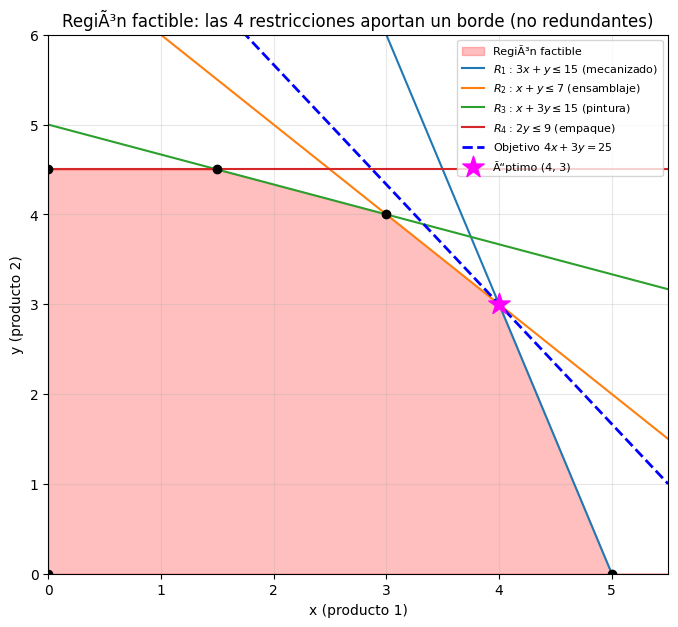

In [7]:
# (1) Region factible con las 4 restricciones: cada una aporta un borde (ninguna redundante)
xf = np.linspace(0, 5.5, 600)
techo = np.minimum.reduce([15 - 3*xf,        # R1: 3x + y <= 15
                           7 - xf,           # R2: x + y <= 7
                           (15 - xf) / 3,    # R3: x + 3y <= 15
                           np.full_like(xf, 4.5)])  # R4: 2y <= 9  -> y <= 4.5
techo = np.clip(techo, 0, None)

plt.figure(figsize=(8, 7))
plt.fill_between(xf, 0, techo, color='red', alpha=0.25, label='RegiÃ³n factible')
plt.plot(xf, 15 - 3*xf, label=r'$R_1:\,3x+y\leq15$ (mecanizado)')
plt.plot(xf, 7 - xf,    label=r'$R_2:\,x+y\leq7$ (ensamblaje)')
plt.plot(xf, (15 - xf)/3, label=r'$R_3:\,x+3y\leq15$ (pintura)')
plt.axhline(4.5, color='C3', label=r'$R_4:\,2y\leq9$ (empaque)')
plt.plot(xf, (25 - 4*xf)/3, 'b--', lw=2, label=r'Objetivo $4x+3y=25$')
for vx, vy in [(0,0),(5,0),(4,3),(3,4),(1.5,4.5),(0,4.5)]:
    plt.scatter([vx],[vy], color='black', zorder=5)
plt.scatter([4],[3], color='magenta', marker='*', s=260, zorder=6, label='Ã“ptimo (4, 3)')
plt.xlim(0, 5.5); plt.ylim(0, 6)
plt.xlabel('x (producto 1)'); plt.ylabel('y (producto 2)')
plt.title('RegiÃ³n factible: las 4 restricciones aportan un borde (no redundantes)')
plt.legend(loc='upper right', fontsize=8); plt.grid(alpha=0.3)
plt.show()

In [8]:
# (2) Resolucion con gurobipy: holgura (.Slack) y precio sombra (.Pi) de cada restriccion
import gurobipy as gp
from gurobipy import GRB
m = gp.Model("cuatro_restricciones")
m.setParam('OutputFlag', 0)
x = m.addVar(lb=0, name="x")
y = m.addVar(lb=0, name="y")
R1 = m.addConstr(3*x + y <= 15, name="R1_mecanizado")
R2 = m.addConstr(x + y <= 7,    name="R2_ensamblaje")
R3 = m.addConstr(x + 3*y <= 15, name="R3_pintura")
R4 = m.addConstr(2*y <= 9,      name="R4_empaque")
m.setObjective(4*x + 3*y, GRB.MAXIMIZE)
m.optimize()
print(f"gurobi -> x = {x.X:.2f}, y = {y.X:.2f} | Z* = {m.ObjVal:.2f}\n")
for c in (R1, R2, R3, R4):
    estado = "ACTIVA" if abs(c.Slack) < 1e-9 else "inactiva"
    print(f"  {c.ConstrName:18s}: holgura = {c.Slack:5.2f} | precio sombra (Pi) = {c.Pi:.2f}  ({estado})")

Set parameter Username


Academic license - for non-commercial use only - expires 2027-06-10


gurobi -> x = 4.00, y = 3.00 | Z* = 25.00

  R1_mecanizado     : holgura =  0.00 | precio sombra (Pi) = 0.50  (ACTIVA)
  R2_ensamblaje     : holgura =  0.00 | precio sombra (Pi) = 2.50  (ACTIVA)
  R3_pintura        : holgura =  2.00 | precio sombra (Pi) = 0.00  (inactiva)
  R4_empaque        : holgura =  3.00 | precio sombra (Pi) = 0.00  (inactiva)


In [9]:
# (3) KKT a mano con SOLO las activas (R1, R2). Por holgura complementaria mu3 = mu4 = 0.
# Incognitas [x, y, mu1, mu2]:
#   Estacionariedad:  3*mu1 + mu2 = 4 ;  mu1 + mu2 = 3
#   Activas:          3x + y = 15 ;  x + y = 7
A = np.array([[0, 0, 3, 1],
              [0, 0, 1, 1],
              [3, 1, 0, 0],
              [1, 1, 0, 0]], dtype=float)
b = np.array([4, 3, 15, 7], dtype=float)
x, y, mu1, mu2 = np.linalg.solve(A, b)
print(f"KKT a mano -> (x*, y*) = ({x:.2f}, {y:.2f}) | mu1 = {mu1:.2f}, mu2 = {mu2:.2f}, mu3 = mu4 = 0")
print(f"Z* = {4*x + 3*y:.2f}")
print(">> mu1 y mu2 coinciden con los precios sombra (.Pi) de R1 y R2 de Gurobi.")

KKT a mano -> (x*, y*) = (4.00, 3.00) | mu1 = 0.50, mu2 = 2.50, mu3 = mu4 = 0
Z* = 25.00
>> mu1 y mu2 coinciden con los precios sombra (.Pi) de R1 y R2 de Gurobi.


### DiscusiÃ³n

Con **cuatro** restricciones, la **holgura complementaria** hace casi todo el trabajo: solo dos restricciones son activas ($R_1$ y $R_2$), y las otras dos, al tener holgura positiva, fuerzan $\mu_3 = \mu_4 = 0$. AsÃ­ el problema "grande" se reduce a un sistema de KKT con solo los multiplicadores activos. Gurobi entrega los precios sombra directo en `.Pi`: $0.5$ y $2.5$ para las activas, y $0$ para las inactivas â€”exactamente los $\mu_i$ del cÃ¡lculo a manoâ€”. La lectura de negocio: la planta deberÃ­a invertir en ampliar **ensamblaje** ($\mu_2 = 2.5$) antes que mecanizado ($\mu_1 = 0.5$); gastar en pintura o empaque no rinde nada mientras esas restricciones tengan holgura. El grÃ¡fico confirma que ninguna restricciÃ³n es redundante: las cuatro aportan un lado del polÃ­gono factible.